# Optimization of Industrial Uptime: A Comparative Analysis of Machine Failure Prediction using GMMs, Support Vector Machines and Decision Trees

**Dataset:** Predictive Maintenance Dataset (AI4I 2020)  
**Module:** Data Analytics ECS784U/P  
**Date:** 16/03/2026


### 1) Exporatory Data Analysis Using Pandas

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report, precision_score, recall_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import svm


In [52]:
df = pd.read_csv('ai4i2020.csv')
print(df.columns)
print(df.dtypes)
print(df.shape)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
(10000, 14)


In [53]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [54]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [56]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [57]:
print('Values and counts for Machine failure are:')
print(df['Machine failure'].value_counts())


Values and counts for Machine failure are:
Machine failure
0    9661
1     339
Name: count, dtype: int64


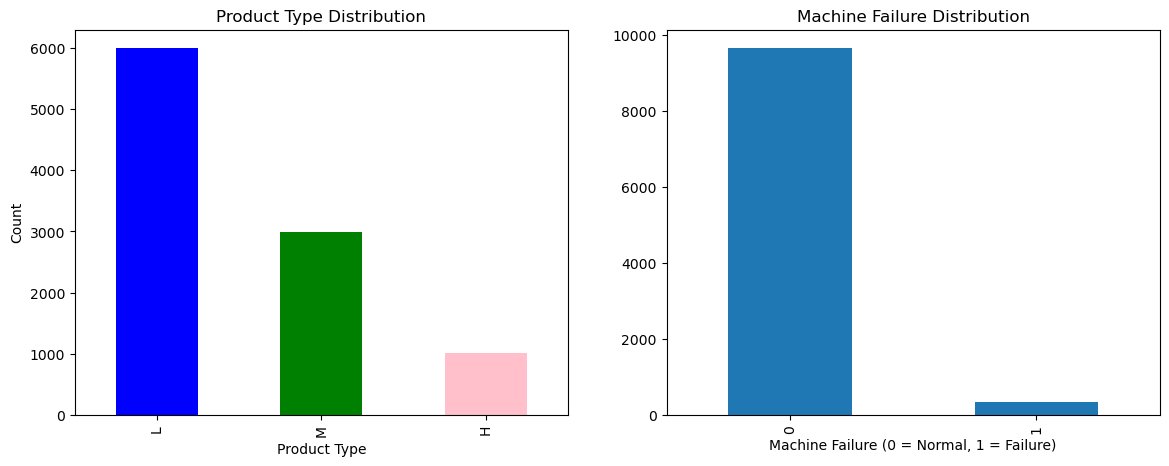

In [58]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 5))
df['Type'].value_counts().plot(ax = axes[0], kind = 'bar',
                               title = 'Product Type Distribution',
                               color = ['blue', 'green', 'pink'],
                               ylabel = 'Count', xlabel = 'Product Type')
df['Machine failure'].value_counts().plot(ax = axes[1], kind = 'bar',
                                          title = 'Machine Failure Distribution',
                                          xlabel = 'Machine Failure (0 = Normal, 1 = Failure)')
plt.show()

Counts for type vs. machine failure: 
Machine failure     0    1
Type                      
H                 982   21
L                5765  235
M                2914   83


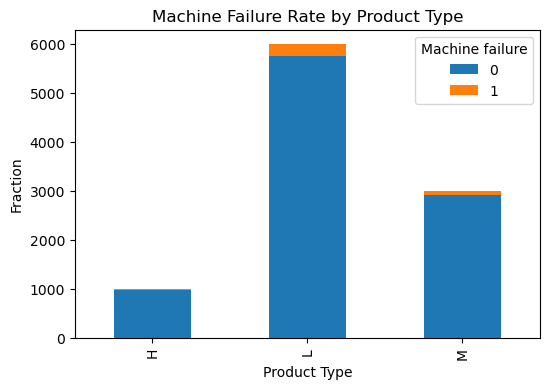

In [59]:
type_status = pd.crosstab(df['Type'], df['Machine failure'])
print("Counts for type vs. machine failure: ")
print(type_status)

type_status.plot(kind = 'bar', stacked = True, figsize = (6, 4),
                 xlabel = 'Product Type', ylabel = 'Fraction', 
                 title = 'Machine Failure Rate by Product Type')
plt.show()

In [60]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
any_mode_active = df[failure_modes].sum(axis = 1) > 0
inconsistency = df[any_mode_active & (df['Machine failure'] == 0)]

print(f"Total rows where failure modes are active but machine failure is 0: {len(inconsistency)}")
print("Breakdown by failure:")
for mode in failure_modes:
    count = len(df[(df[mode] ==1) & (df['Machine failure'] == 0)])
    print(f"{mode}: {count} inconsistent rows")

no_mode_but_failed = df[(df['Machine failure'] ==1) & (any_mode_active == False)]
print(f"\nRows where Machine failure = 1 but no specific mode fires: {len(no_mode_but_failed)}")

Total rows where failure modes are active but machine failure is 0: 18
Breakdown by failure:
TWF: 0 inconsistent rows
HDF: 0 inconsistent rows
PWF: 0 inconsistent rows
OSF: 0 inconsistent rows
RNF: 18 inconsistent rows

Rows where Machine failure = 1 but no specific mode fires: 9


In [61]:
df['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Torque [Nm]']* (2* np.pi* df['Rotational speed [rpm]']/60)
df['Strain'] = df['Tool wear [min]'] * df['Torque [Nm]']
print(df.columns.tolist())
df[['Temp_Diff', 'Power', 'Strain']].describe()

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temp_Diff', 'Power', 'Strain']


,Temp_Diff,Power,Strain
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550
std,1.001094,1067.418295,2826.567692
min,7.600000,1148.440610,0.000000
25%,9.300000,5561.184484,1963.650000
50%,9.800000,6271.027344,4012.950000
75%,11.000000,7003.002724,6279.000000
max,12.100000,10469.923005,16497.000000


In [62]:
print('Type is originally a string variable:')
print(df['Type'].value_counts())

df['Type'] = df['Type'].astype('category').cat.codes
print('\nType has been converted to integer: ')
print(df['Type'].value_counts())

df.head()

Type is originally a string variable:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Type has been converted to integer: 
Type
1    6000
2    2997
0    1003
Name: count, dtype: int64


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temp_Diff,Power,Strain
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560,0.0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724,138.9
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543,247.0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659,276.5
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608,360.0


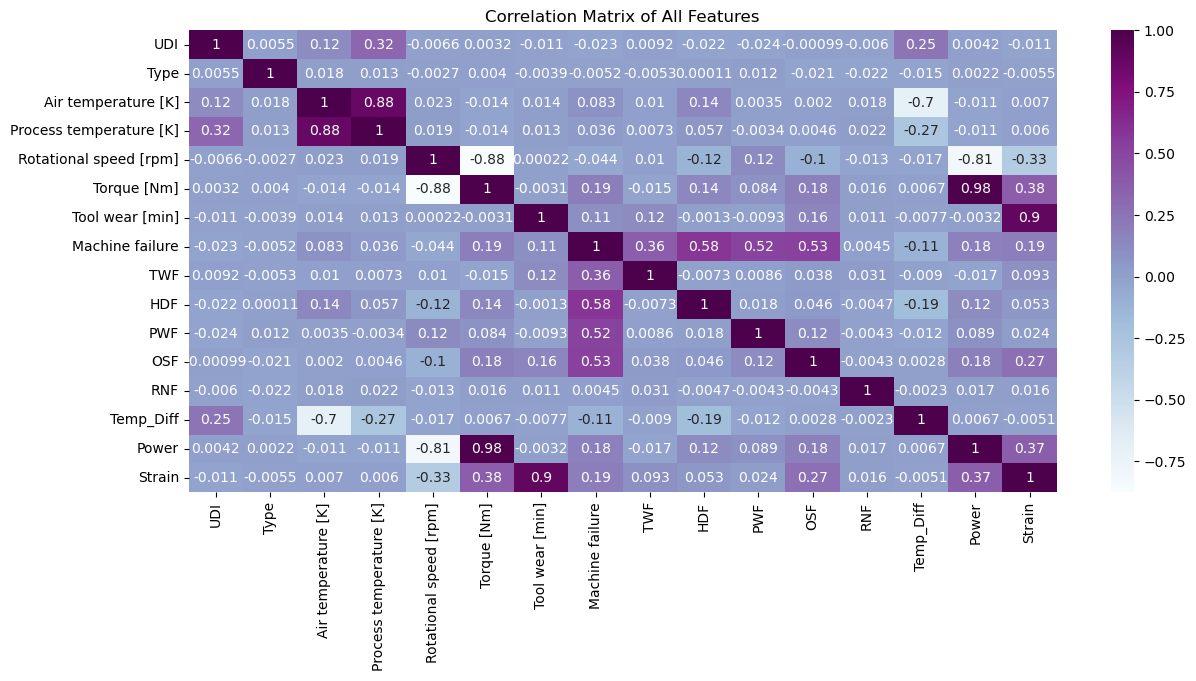

In [63]:
corr = df.select_dtypes(include = ['number']).corr()
plt.figure(figsize=(14, 6))
sns.heatmap(corr, annot=True, cmap='BuPu')
plt.title('Correlation Matrix of All Features')
plt.show()

In [64]:
data = {
    'Failure Mode': ['HDF (Heat Dissipation)', 'OSF (Overstrain)', 'PWF (Power)', 'TWF (Tool Wear)', 'RNF (Random)'],
    'Correlation to Machine Failure': [0.58, 0.53, 0.52, 0.36, 0.0045]
}

df_corr = pd.DataFrame(data).sort_values(by='Correlation to Machine Failure', ascending=False)
print(df_corr)

             Failure Mode  Correlation to Machine Failure
0  HDF (Heat Dissipation)                          0.5800
1        OSF (Overstrain)                          0.5300
2             PWF (Power)                          0.5200
3         TWF (Tool Wear)                          0.3600
4            RNF (Random)                          0.0045


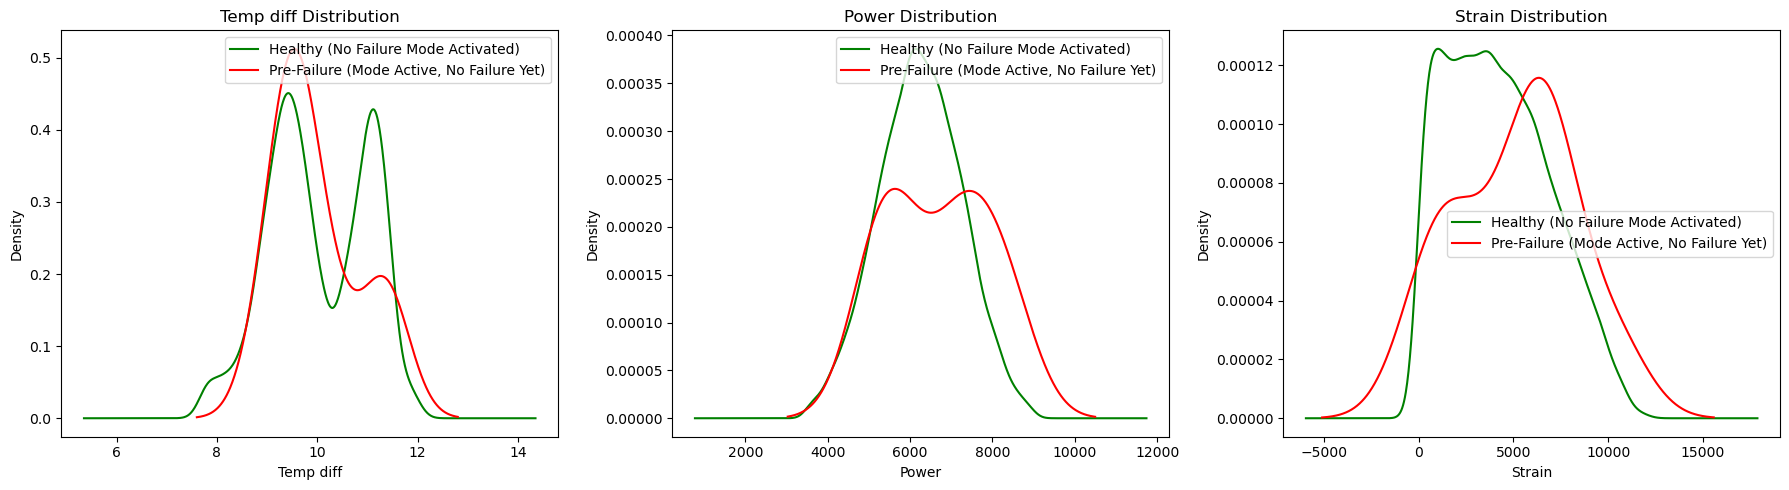

In [86]:
pre_failure = df[(df['Machine failure'] == 0) & any_mode_active]
healthy = df[(df['Machine failure'] == 0) & ~any_mode_active]

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (18, 5))
for ax, col in zip (axes, ['Temp_Diff', 'Power', 'Strain']):
    healthy[col].plot(kind = 'density', ax=ax, label = 'Healthy (No Failure Mode Activated)', color = 'green')
    pre_failure[col].plot(kind = 'density', ax=ax, label = 'Pre-Failure (Mode Active, No Failure Yet)', color = 'red')
    ax.set_title(f'{col.replace("_", " ").capitalize()} Distribution')
    ax.set_xlabel(col.replace("_", " ").capitalize())
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()
    


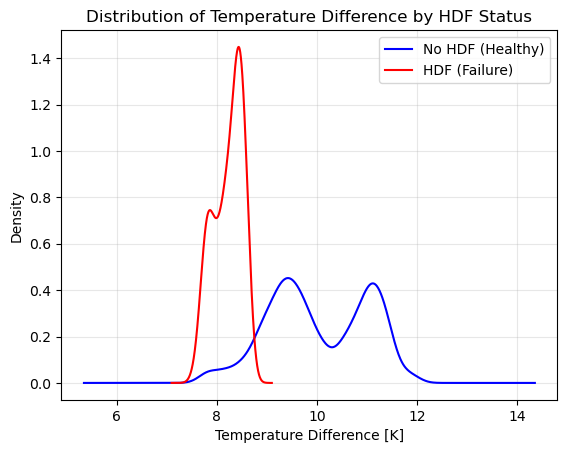

In [66]:
df[df['HDF'] == 0]['Temp_Diff'].plot(kind='density', label='No HDF (Healthy)', color='blue')
df[df['HDF'] == 1]['Temp_Diff'].plot(kind='density', label='HDF (Failure)', color='red')

plt.title('Distribution of Temperature Difference by HDF Status')
plt.xlabel('Temperature Difference [K]')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

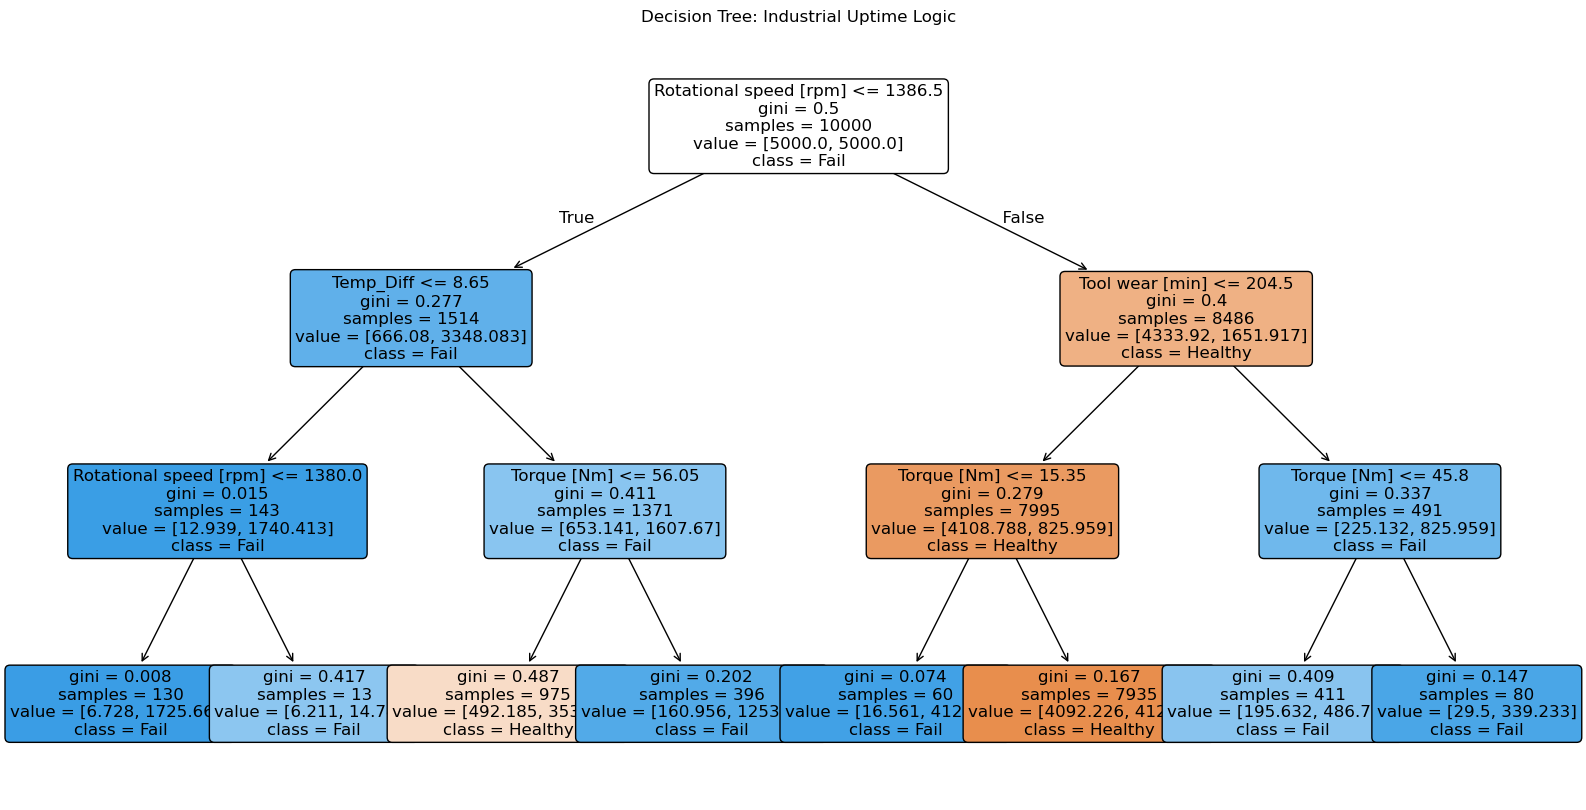

In [67]:
#decision tree for HDF & temp_diff
X_tree = df[['Type', 'Torque [Nm]', 'Rotational speed [rpm]', 'Tool wear [min]', 'Temp_Diff']]
y_tree = df['Machine failure']

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
tree_model.fit(X_tree, y_tree)

plt.figure(figsize=(20, 10))
plot_tree(tree_model, 
          feature_names=list(X_tree.columns), 
          class_names=['Healthy', 'Fail'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Decision Tree: Industrial Uptime Logic")
plt.show()

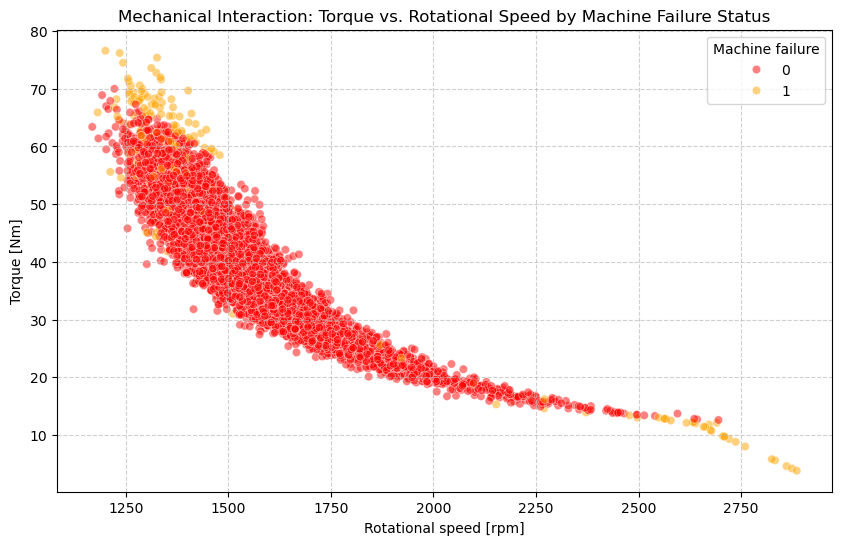

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data = df, x='Rotational speed [rpm]', y = 'Torque [Nm]',
                hue = 'Machine failure', alpha = 0.5, palette = ['red', 'orange'])
plt.title('Mechanical Interaction: Torque vs. Rotational Speed by Machine Failure Status')
plt.grid(True, linestyle='--', alpha = 0.6)
plt.show()

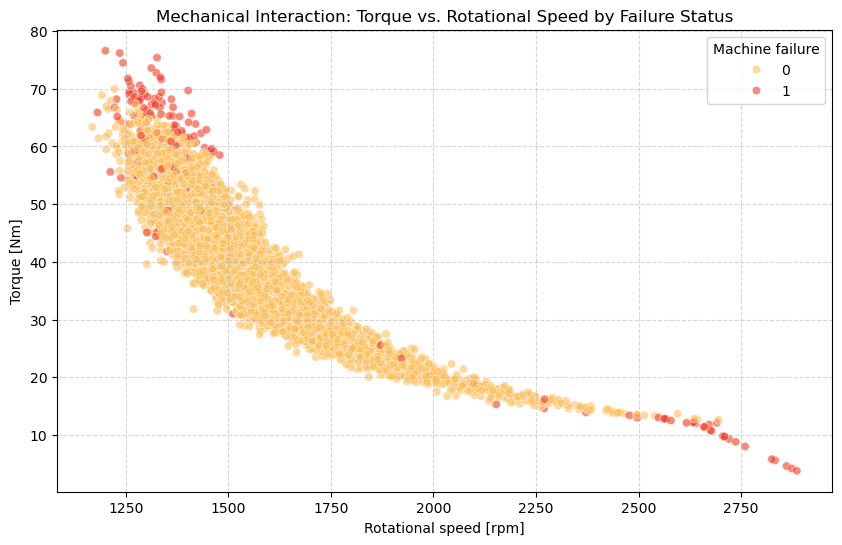

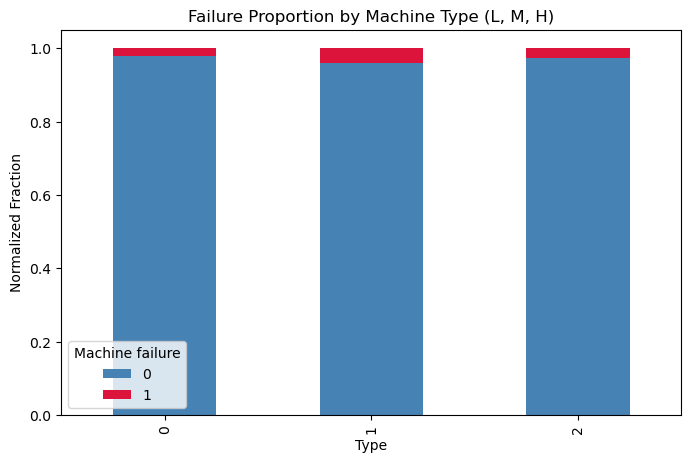

In [69]:
#Speed vs. Torque
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rotational speed [rpm]', y='Torque [Nm]', 
                hue='Machine failure', alpha=0.6, palette='YlOrRd')
plt.title('Mechanical Interaction: Torque vs. Rotational Speed by Failure Status')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Categorical Analysis: Machine Type impact
type_fail = pd.crosstab(df['Type'], df['Machine failure'], normalize='index')
type_fail.plot(kind='bar', stacked=True, color=['steelblue', 'crimson'], figsize=(8, 5))
plt.title('Failure Proportion by Machine Type (L, M, H)')
plt.ylabel('Normalized Fraction')
plt.show()

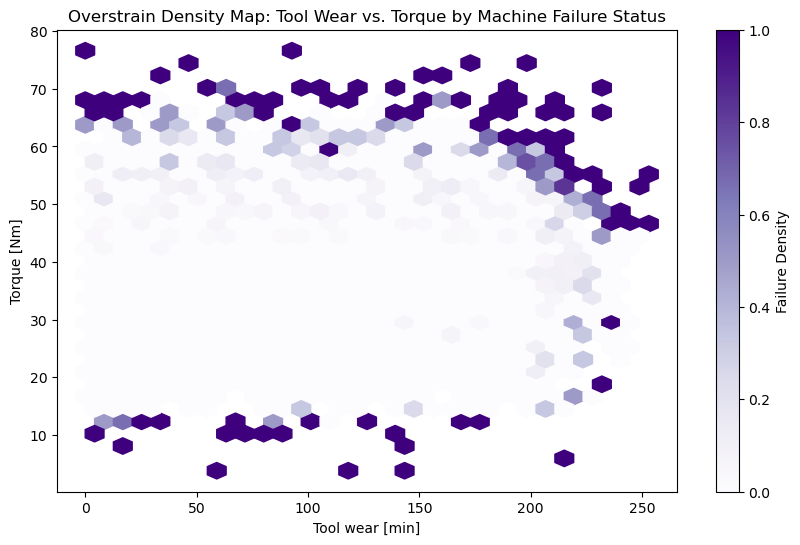

In [70]:
plt.figure(figsize = (10, 6))
plt.hexbin(df['Tool wear [min]'], df['Torque [Nm]'], C=df['Machine failure'],
           gridsize=30, cmap='Purples')
plt.colorbar(label= 'Failure Density')
plt.xlabel('Tool wear [min]')
plt.ylabel('Torque [Nm]')
plt.title('Overstrain Density Map: Tool Wear vs. Torque by Machine Failure Status')
plt.show()

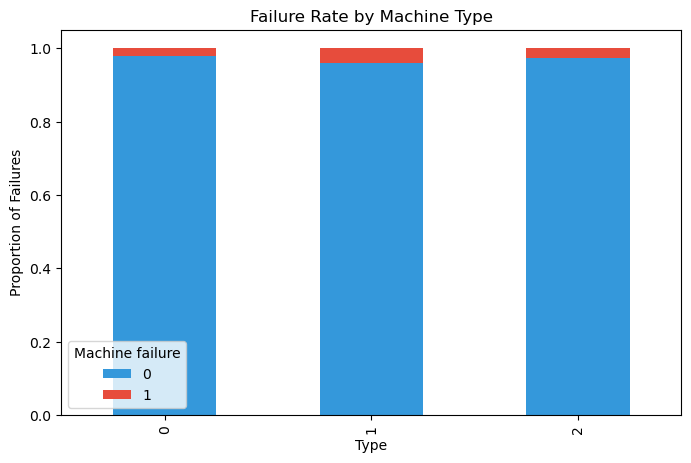

In [71]:
type_analysis = pd.crosstab(df['Type'], df['Machine failure'], normalize='index')
type_analysis.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], figsize=(8, 5))
plt.title('Failure Rate by Machine Type')
plt.ylabel('Proportion of Failures')
plt.show()

<Axes: title={'center': 'Log: Rotational Speed Distribution'}, ylabel='Frequency'>

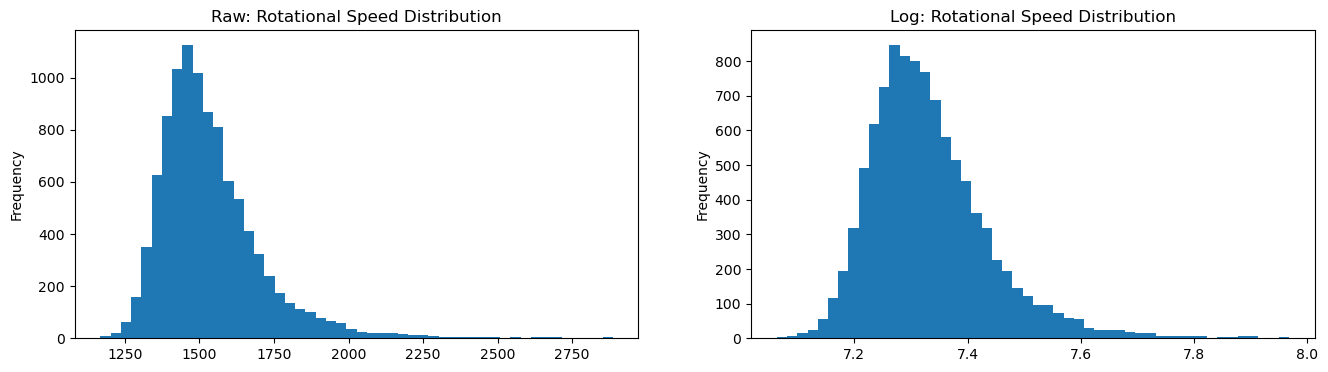

In [72]:
df['Rotational_Speed_Log'] = np.log(df['Rotational speed [rpm]'])
df['Torque_Log'] = np.log(df['Torque [Nm]'])
df['Tool_Wear_Log'] = np.log(df['Tool wear [min]'].replace(0, 1))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
df['Rotational speed [rpm]'].plot(kind='hist', bins=50, ax=axes[0],
                                  title='Raw: Rotational Speed Distribution')
df['Rotational_Speed_Log'].plot(kind='hist', bins=50, ax=axes[1],
                                title='Log: Rotational Speed Distribution')

In [73]:
df = df.drop(['UDI', 'Product ID'], axis=1)

X = df.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']

print(f"Features: {X.columns.tolist()}")
print(f"Feature matrix shape: {X.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"\nFailure rate: {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power', 'Strain', 'Rotational_Speed_Log', 'Torque_Log', 'Tool_Wear_Log']
Feature matrix shape: (10000, 12)

Class distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.4%

Train: 8000 samples, Test: 2000 samples


### 2) Clustering Using Gaussian Mixture Models (GMM)

GMMs identify latent operating regimes in the sensor data using soft probabilistic clustering. The optimal number of components is selected via Bayesian Information Criterion (BIC).

n_components=2: BIC = -70667.61
n_components=3: BIC = -98936.10
n_components=4: BIC = -120225.05
n_components=5: BIC = -136556.05
n_components=6: BIC = -150093.80
n_components=7: BIC = -155891.76


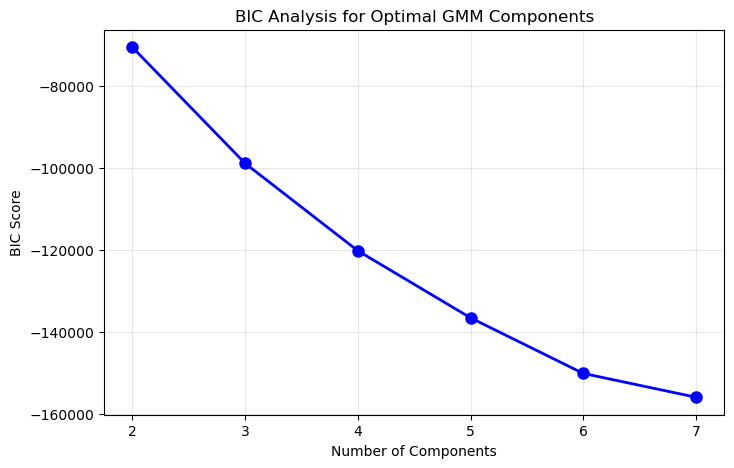

In [87]:
bic_scores = []
n_range = range(2, 8)

for n in n_range:
    gmm_temp = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm_temp.fit(X_train_scaled)
    bic = gmm_temp.bic(X_train_scaled)
    bic_scores.append(bic)
    print(f"n_components={n}: BIC = {bic:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(list(n_range), bic_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.title('BIC Analysis for Optimal GMM Components')
plt.grid(True, alpha=0.3)
plt.show()


In [75]:
gmm = GaussianMixture(n_components=2, random_state=42, n_init=5)
gmm.fit(X_train_scaled)

train_clusters = gmm.predict(X_train_scaled)
test_clusters = gmm.predict(X_test_scaled)
train_probs = gmm.predict_proba(X_train_scaled)
test_probs = gmm.predict_proba(X_test_scaled)

print("Cluster Analysis Failure Rates:")
for c in range(3):
    mask = train_clusters == c
    n_total = mask.sum()
    n_fail = y_train.values[mask].sum()
    rate = n_fail / n_total * 100
    print(f"  Cluster {c}: {n_total:>4d} samples, {n_fail:>3d} failures ({rate:.1f}% failure rate)")

print(f"\nCluster sizes: {pd.Series(train_clusters).value_counts().sort_index().to_dict()}")

Cluster Analysis Failure Rates:
  Cluster 0: 5478 samples, 236 failures (4.3% failure rate)
  Cluster 1: 2522 samples,  42 failures (1.7% failure rate)
  Cluster 2:    0 samples,   0 failures (nan% failure rate)

Cluster sizes: {0: 5478, 1: 2522}


/var/folders/5_/kgft1r2x5h54741j45q93kxc0000gn/T/ipykernel_19380/1912092006.py:14: RuntimeWarning: invalid value encountered in scalar divide
  rate = n_fail / n_total * 100


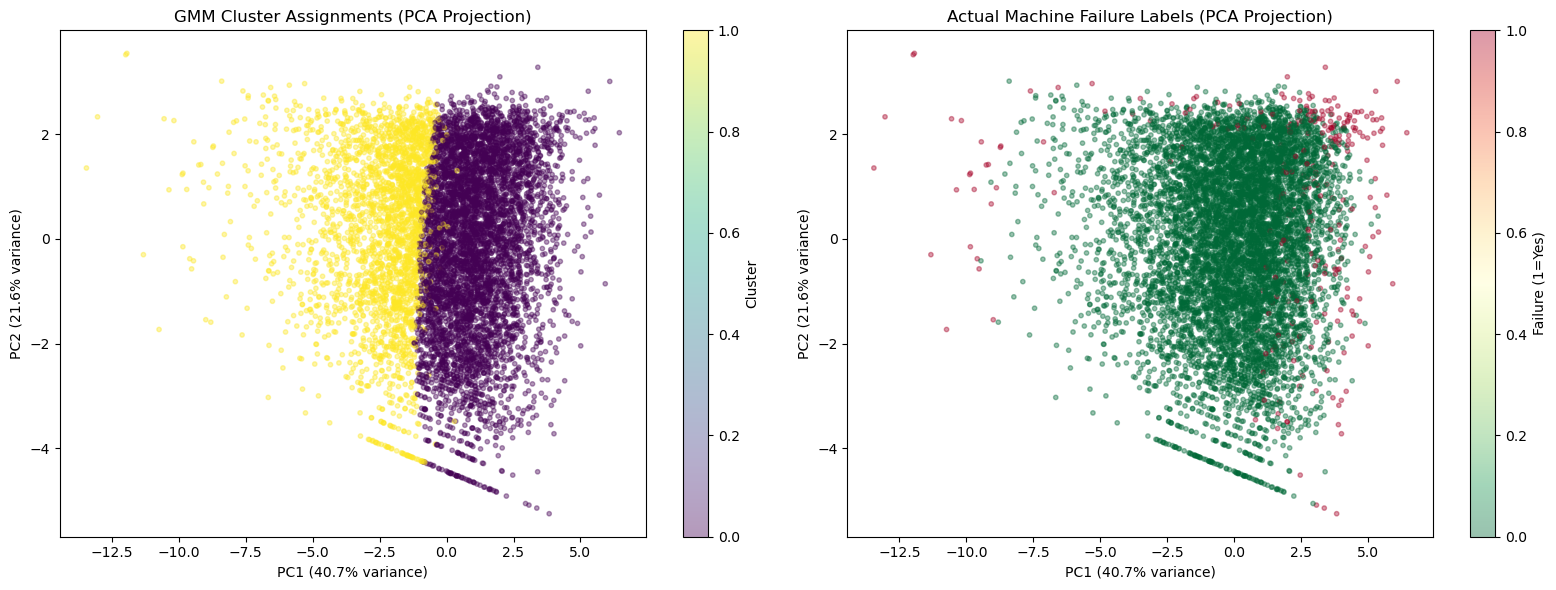

In [76]:
#pca for cluster visualisation
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                           c=train_clusters, cmap='viridis', alpha=0.4, s=10)
axes[0].set_title('GMM Cluster Assignments (PCA Projection)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                           c=y_train.values, cmap='RdYlGn_r', alpha=0.4, s=10)
axes[1].set_title('Actual Machine Failure Labels (PCA Projection)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter2, ax=axes[1], label='Failure (1=Yes)')

plt.tight_layout()
plt.show()

Anomaly threshold (5th percentile): -3.4502

GMM Anomaly Detection Results:
  Accuracy:  0.9350
  F1-Score:  0.2778
  Precision: 0.2101
  Recall:    0.4098


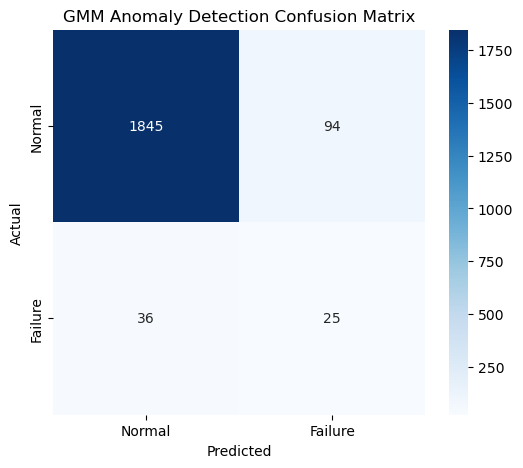


Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.97      1939
     Failure       0.21      0.41      0.28        61

    accuracy                           0.94      2000
   macro avg       0.60      0.68      0.62      2000
weighted avg       0.96      0.94      0.94      2000



In [77]:
#points with low log-likelihood are in low-density regions (potential anomalies)
train_scores = gmm.score_samples(X_train_scaled)
test_scores = gmm.score_samples(X_test_scaled)

threshold = np.percentile(train_scores, 5)
gmm_preds = (test_scores < threshold).astype(int)

print(f"Anomaly threshold (5th percentile): {threshold:.4f}")
print(f"\nGMM Anomaly Detection Results:")
print(f"  Accuracy:  {accuracy_score(y_test, gmm_preds):.4f}")
print(f"  F1-Score:  {f1_score(y_test, gmm_preds):.4f}")
print(f"  Precision: {precision_score(y_test, gmm_preds):.4f}")
print(f"  Recall:    {recall_score(y_test, gmm_preds):.4f}")

cm_gmm = confusion_matrix(y_test, gmm_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gmm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('GMM Anomaly Detection Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"\nClassification Report:")
print(classification_report(y_test, gmm_preds, target_names=['Normal', 'Failure']))

### 3) Classification Using Support Vector Machines (SVM)

Two SVM models are compared: a baseline using the 9 sensor/engineered features, and an augmented model that includes GMM cluster assignments and probabilities as additional features. Both use RBF kernel with balanced class weights to address the 6.4% minority class.

Baseline SVM (RBF kernel, 9 features):
  Accuracy:  0.9235
  F1-Score:  0.4093
  Precision: 0.2677
  Recall:    0.8689


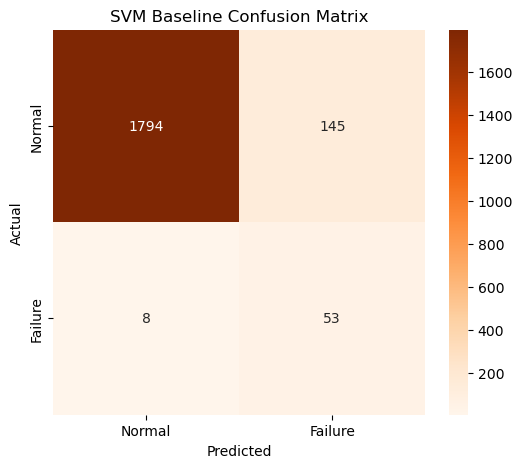


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96      1939
     Failure       0.27      0.87      0.41        61

    accuracy                           0.92      2000
   macro avg       0.63      0.90      0.68      2000
weighted avg       0.97      0.92      0.94      2000



In [78]:
svm_baseline = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_baseline.fit(X_train_scaled, y_train)
y_pred_svm_base = svm_baseline.predict(X_test_scaled)

print("Baseline SVM (RBF kernel, 9 features):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_svm_base):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_svm_base):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_svm_base):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_svm_base):.4f}")

cm_svm = confusion_matrix(y_test, y_pred_svm_base)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('SVM Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm_base, target_names=['Normal', 'Failure']))

Augmented feature matrix: 15 features (9 original + 1 cluster label + 3 cluster probabilities)

Augmented SVM (RBF kernel, 13 features):
  Accuracy:  0.9210
  F1-Score:  0.4015
  Precision: 0.2611
  Recall:    0.8689


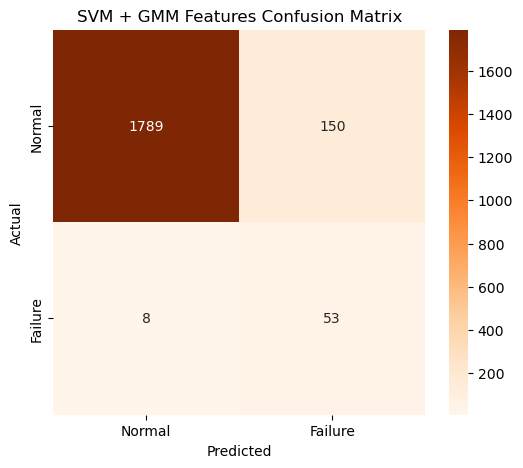


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96      1939
     Failure       0.26      0.87      0.40        61

    accuracy                           0.92      2000
   macro avg       0.63      0.90      0.68      2000
weighted avg       0.97      0.92      0.94      2000



In [79]:
X_train_augmented = np.hstack([X_train_scaled, train_clusters.reshape(-1, 1), train_probs])
X_test_augmented = np.hstack([X_test_scaled, test_clusters.reshape(-1, 1), test_probs])

print(f"Augmented feature matrix: {X_train_augmented.shape[1]} features "
      f"(9 original + 1 cluster label + 3 cluster probabilities)")

svm_augmented = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_augmented.fit(X_train_augmented, y_train)
y_pred_svm_aug = svm_augmented.predict(X_test_augmented)

print(f"\nAugmented SVM (RBF kernel, 13 features):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_svm_aug):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_svm_aug):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_svm_aug):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_svm_aug):.4f}")

cm_svm_aug = confusion_matrix(y_test, y_pred_svm_aug)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm_aug, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('SVM + GMM Features Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm_aug, target_names=['Normal', 'Failure']))

### 4) Classification Using Decision Tree

A Decision Tree classifier provides an interpretable baseline and reveals feature importance rankings. It does not require feature scaling, unlike SVM.

Decision Tree (max_depth=5):
  Accuracy:  0.9425
  F1-Score:  0.4889
  Precision: 0.3354
  Recall:    0.9016


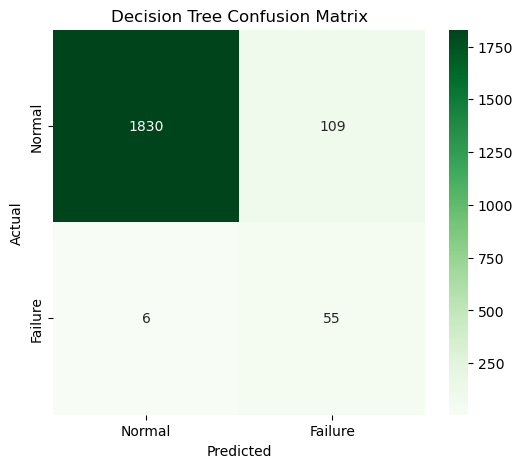


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97      1939
     Failure       0.34      0.90      0.49        61

    accuracy                           0.94      2000
   macro avg       0.67      0.92      0.73      2000
weighted avg       0.98      0.94      0.95      2000



In [80]:
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree (max_depth=5):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_dt):.4f}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Normal', 'Failure']))

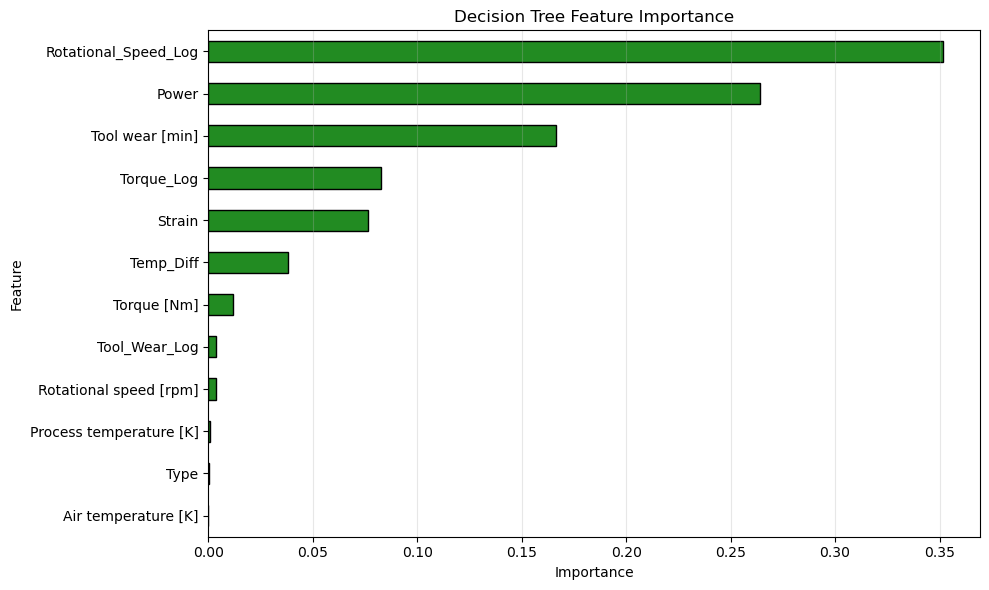

Top 3 most important features:
  Rotational_Speed_Log: 0.3518
  Power: 0.2639
  Tool wear [min]: 0.1665


In [81]:
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='forestgreen', edgecolor='black')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {imp:.4f}")

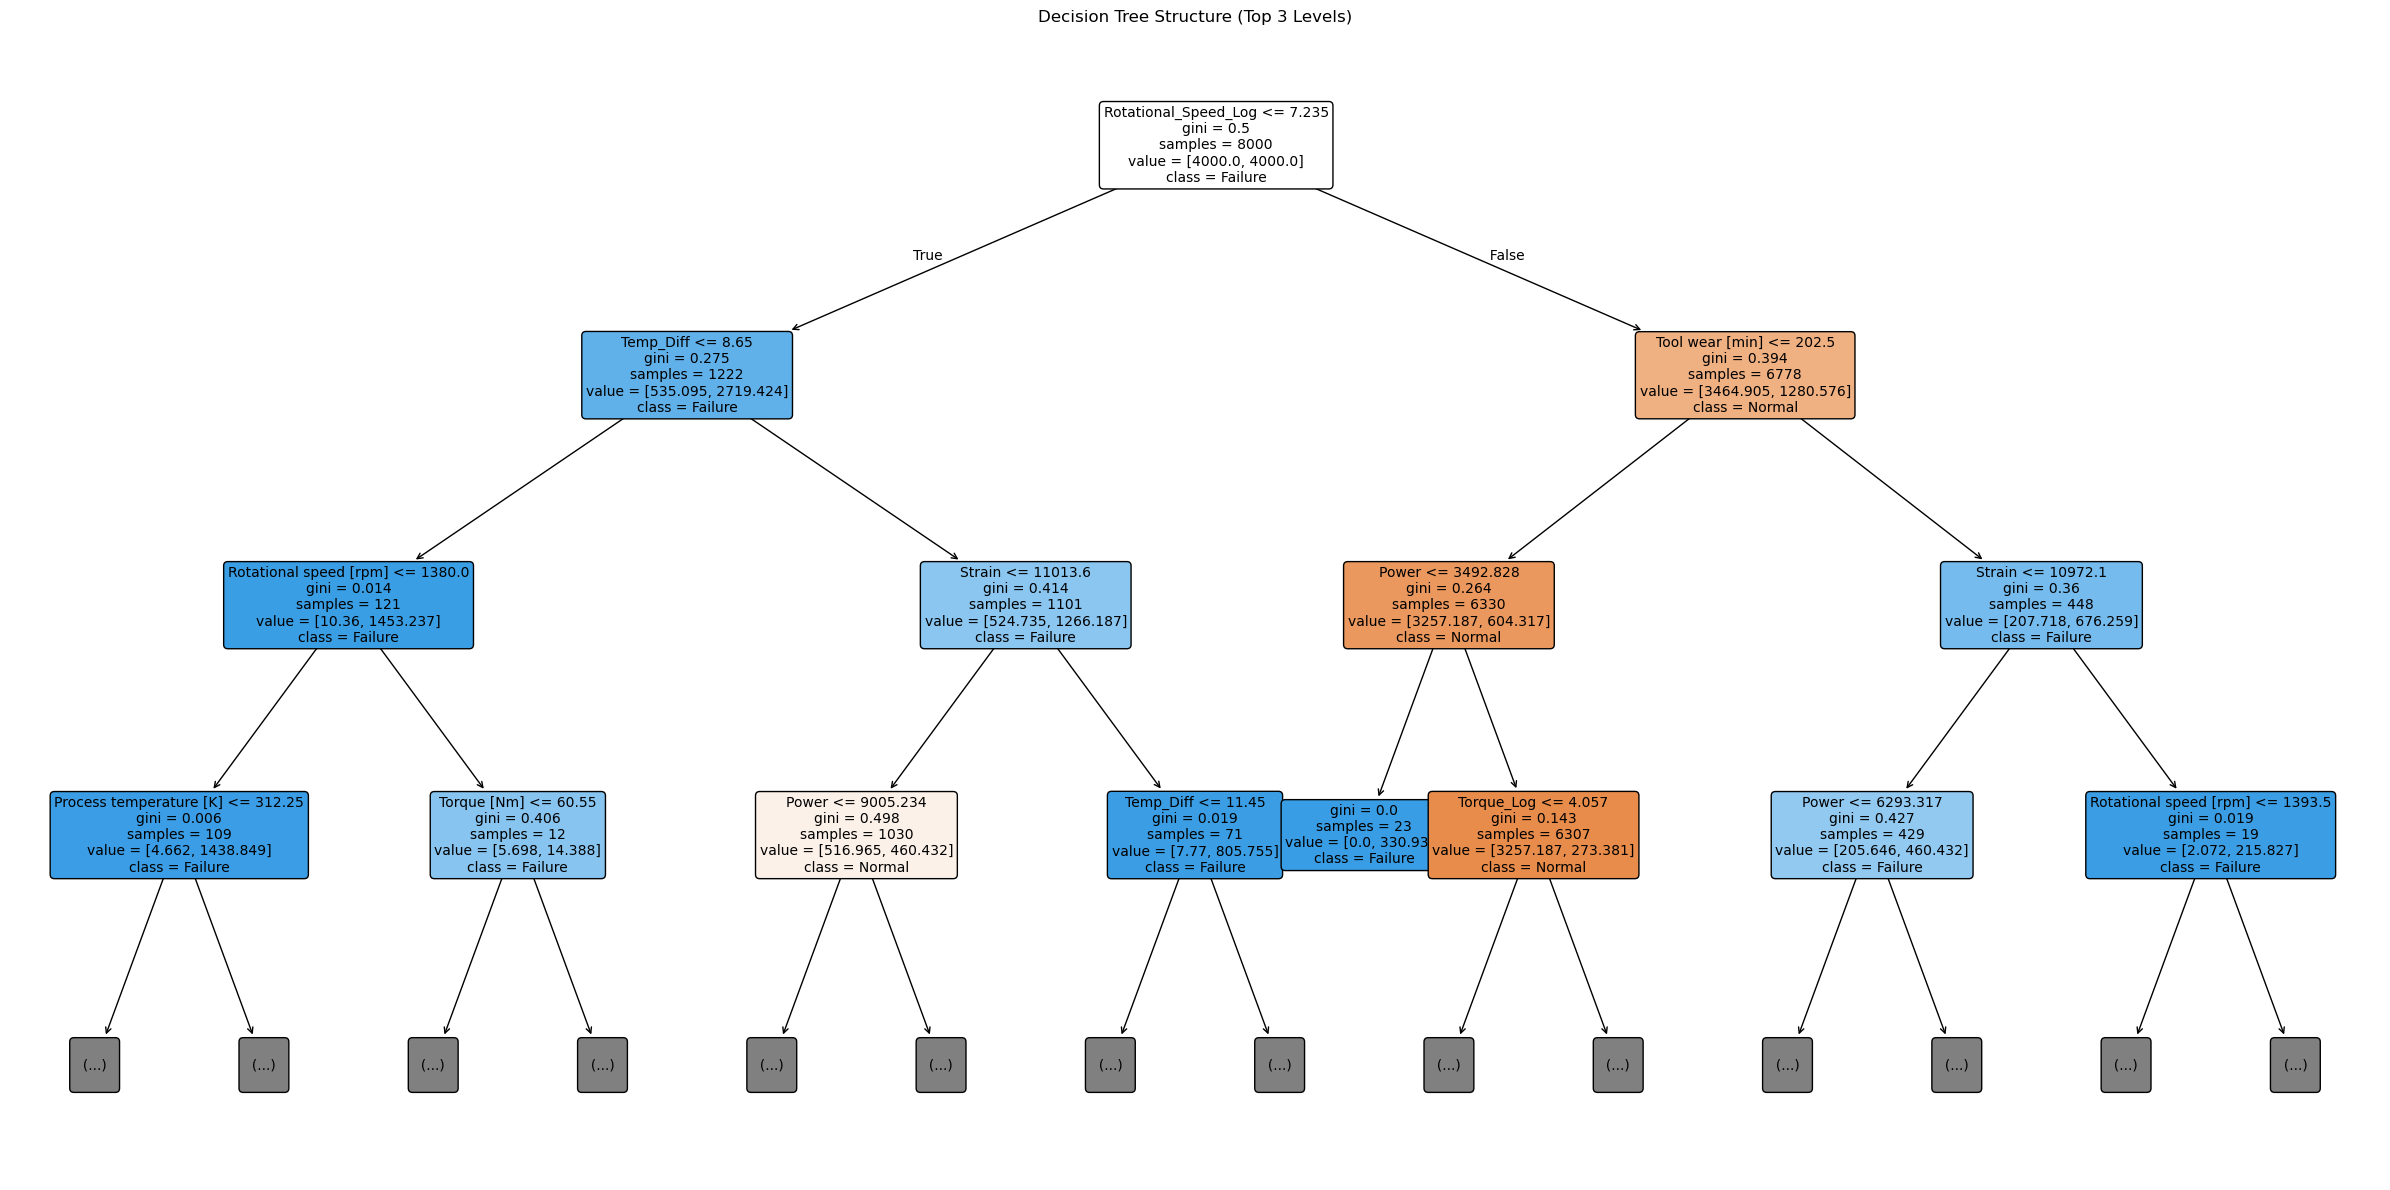

In [82]:
plt.figure(figsize=(24, 12))
plot_tree(dt_model, 
          feature_names=list(X.columns), 
          class_names=['Normal', 'Failure'], 
          filled=True, rounded=True, fontsize=10,
          max_depth=3)  # show top 3 levels for readability
plt.title("Decision Tree Structure (Top 3 Levels)")
plt.tight_layout()
plt.show()

### 5) Cross-Validation and Model Comparison

5-fold stratified cross-validation ensures robust performance estimates. Stratification preserves the class imbalance ratio in each fold.

In [83]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_cv_f1 = cross_val_score(SVC(kernel='rbf', class_weight='balanced', random_state=42),
                            X_train_scaled, y_train, cv=cv, scoring='f1')
svm_cv_acc = cross_val_score(SVC(kernel='rbf', class_weight='balanced', random_state=42),
                             X_train_scaled, y_train, cv=cv, scoring='accuracy')

dt_cv_f1 = cross_val_score(DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
                           X_train, y_train, cv=cv, scoring='f1')
dt_cv_acc = cross_val_score(DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
                            X_train, y_train, cv=cv, scoring='accuracy')

print("5-Fold Stratified Cross-Validation Results:")
print(f"{'Model':<20} {'Metric':<10} {'Mean':>8} {'Std':>8}")
print(f"{'SVM (RBF)':<20} {'F1':<10} {svm_cv_f1.mean():>8.4f} {svm_cv_f1.std():>8.4f}")
print(f"{'SVM (RBF)':<20} {'Accuracy':<10} {svm_cv_acc.mean():>8.4f} {svm_cv_acc.std():>8.4f}")
print(f"{'Decision Tree':<20} {'F1':<10} {dt_cv_f1.mean():>8.4f} {dt_cv_f1.std():>8.4f}")
print(f"{'Decision Tree':<20} {'Accuracy':<10} {dt_cv_acc.mean():>8.4f} {dt_cv_acc.std():>8.4f}")

5-Fold Stratified Cross-Validation Results:
Model                Metric         Mean      Std
SVM (RBF)            F1           0.4763   0.0246
SVM (RBF)            Accuracy     0.9311   0.0058
Decision Tree        F1           0.5754   0.0224
Decision Tree        Accuracy     0.9545   0.0044


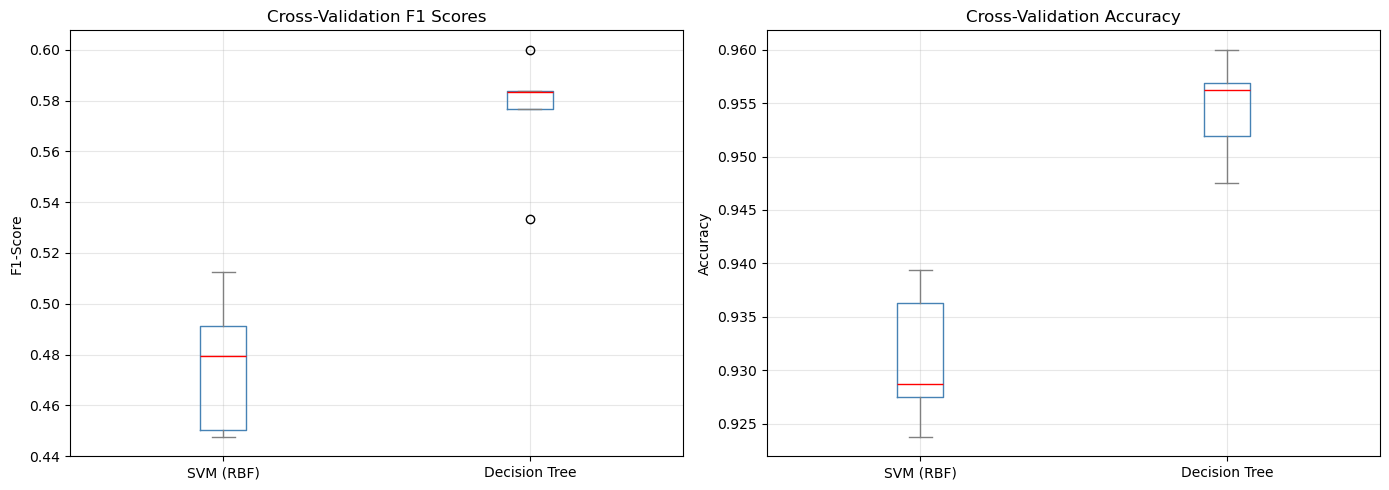

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cv_f1_data = pd.DataFrame({'SVM (RBF)': svm_cv_f1, 'Decision Tree': dt_cv_f1})
cv_f1_data.plot(kind='box', ax=axes[0], color=dict(boxes='steelblue', whiskers='gray', 
                                                     medians='red', caps='gray'))
axes[0].set_title('Cross-Validation F1 Scores')
axes[0].set_ylabel('F1-Score')
axes[0].grid(True, alpha=0.3)

cv_acc_data = pd.DataFrame({'SVM (RBF)': svm_cv_acc, 'Decision Tree': dt_cv_acc})
cv_acc_data.plot(kind='box', ax=axes[1], color=dict(boxes='steelblue', whiskers='gray',
                                                      medians='red', caps='gray'))
axes[1].set_title('Cross-Validation Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6) Summary Comparison

Model Comparison Summary:
                  Model  Accuracy  F1-Score  Precision  Recall
GMM (Anomaly Detection)    0.9350    0.2778     0.2101  0.4098
           SVM Baseline    0.9235    0.4093     0.2677  0.8689
     SVM + GMM Features    0.9210    0.4015     0.2611  0.8689
          Decision Tree    0.9425    0.4889     0.3354  0.9016


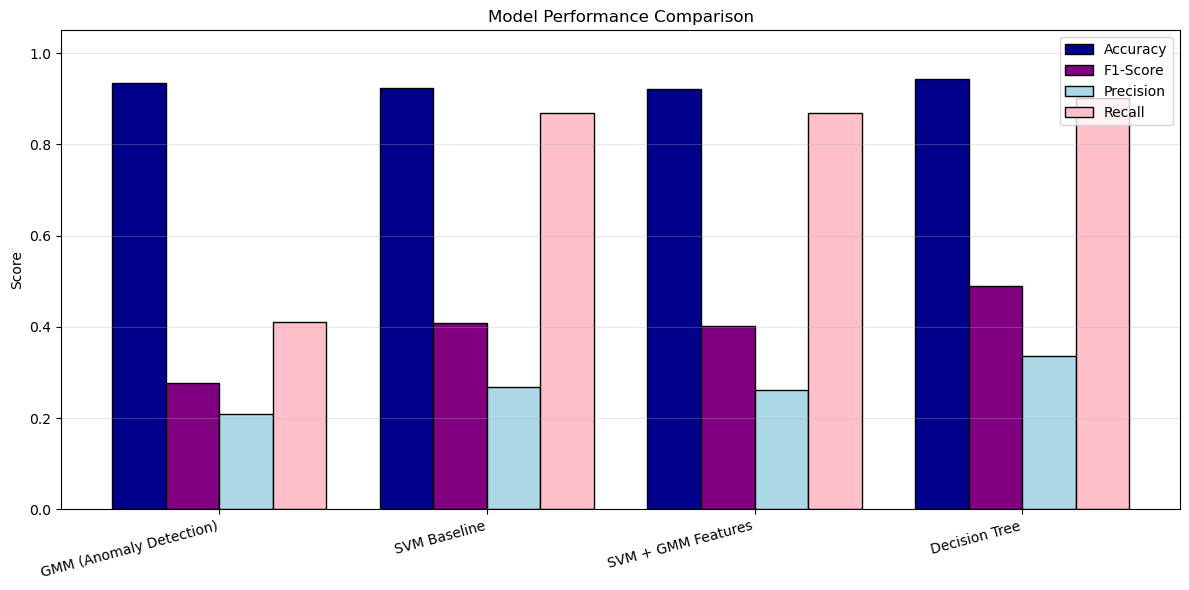

In [85]:
results = pd.DataFrame({
    'Model': ['GMM (Anomaly Detection)', 'SVM Baseline', 'SVM + GMM Features', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, gmm_preds), accuracy_score(y_test, y_pred_svm_base),
                 accuracy_score(y_test, y_pred_svm_aug), accuracy_score(y_test, y_pred_dt)],
    'F1-Score': [f1_score(y_test, gmm_preds), f1_score(y_test, y_pred_svm_base),
                 f1_score(y_test, y_pred_svm_aug), f1_score(y_test, y_pred_dt)],
    'Precision': [precision_score(y_test, gmm_preds), precision_score(y_test, y_pred_svm_base),
                  precision_score(y_test, y_pred_svm_aug), precision_score(y_test, y_pred_dt)],
    'Recall': [recall_score(y_test, gmm_preds), recall_score(y_test, y_pred_svm_base),
               recall_score(y_test, y_pred_svm_aug), recall_score(y_test, y_pred_dt)]
})

print("Model Comparison Summary:")
print(results.to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results))
width = 0.2
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
colors = ['darkblue', 'purple', 'lightblue', 'pink']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results[metric], width, label=metric, color=color, edgecolor='black')

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()